---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 10 — Transferência de Estilo com Redes Neurais

Neste notebook, exploramos o conceito de **transferência de estilo neural (Neural Style Transfer)** — uma das aplicações mais visuais e intuitivas das redes convolucionais.  
A ideia central é **gerar uma nova imagem** que combine:

- o **conteúdo** de uma imagem (ex: uma fotografia real)  
- com o **estilo** de outra (ex: uma pintura de Van Gogh)

Esta técnica, introduzida por **Gatys et al. (2015)**, mostra como redes treinadas para reconhecimento de objetos (como a VGG-19) capturam **características hierárquicas** que também podem ser manipuladas artisticamente.

## 10.1. Preparar as bibliotecas

**Carregamento das bibliotecas principais:**  
   - `torch`, `torchvision`, `PIL` e `matplotlib` para processamento e visualização.  
   - `torchvision.models` para aceder a redes pré-treinadas (usaremos a **VGG-19**, treinada no ImageNet).  
   - `copy` para duplicar modelos e camadas sem alterar o original.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import save_image
from torchvision.models import VGG19_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import copy
import requests
from io import BytesIO
import insightface
from insightface.app import FaceAnalysis
from diffusers import StableDiffusionPipeline
from tqdm import tqdm

/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
W1012 18:01:18.026000 1454 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.uti

## 10.2. Funções utilitárias para carregar e mostrar imagens

Antes de aplicar o modelo, são definidas duas funções utilitárias:  
uma para **carregar e preparar imagens** para a rede, e outra para **as visualizar** após processamento.

 `image_loader(image_name, max_size=512)`

Esta função:
1. **Abre a imagem** com a biblioteca PIL e garante que está em modo RGB.  
2. **Redimensiona** proporcionalmente para que o lado maior não ultrapasse `max_size` píxeis — isto evita sobrecarga de memória.  
3. **Transforma a imagem em tensor PyTorch** através de uma sequência de transformações (`transforms.Compose`):
   - `ToTensor()` → converte para tensor com valores entre 0 e 1.  
   - `Lambda(lambda x: x[:3, :, :])` → assegura que só há três canais (RGB).  
   - `Normalize(mean, std)` → normaliza segundo as médias e desvios padrão usados na rede VGG-19 (`ImageNet`), garantindo compatibilidade.  
4. **Adiciona uma dimensão de batch** (`unsqueeze(0)`), necessária para alimentar a rede.  
5. **Envia o tensor para o dispositivo adequado** (`cuda` se disponível).

 `imshow(tensor, title=None)`

Esta função reverte parte do processo para mostrar a imagem:
1. **Remove gradientes e converte para CPU**, para evitar interferência do autograd.  
2. **Remove a dimensão de batch** (`squeeze(0)`) e limita os valores a [0, 1].  
3. **Converte o tensor em imagem PIL** para visualização.  
4. **Mostra a imagem com Matplotlib**, opcionalmente com título.

**Nota pedagógica**
Estas funções ilustram o fluxo típico de manipulação de imagens em *Deep Learning*:
- **normalizar** para compatibilidade com redes pré-treinadas,  
- **denormalizar** (ou reverter parcialmente) para visualização humana.  

Este processo é fundamental para garantir que as ativações internas da rede correspondem ao espaço de cores e amplitude que o modelo “espera” — uma diferença aparentemente pequena que tem impacto enorme no resultado visual da *style transfer*.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def image_loader(image_name, max_size=512):
    image = Image.open(image_name).convert('RGB')
    size = max(image.size)
    if size > max_size:
        scale = max_size / size
        new_size = [int(x * scale) for x in image.size]
        image = image.resize(new_size, Image.ANTIALIAS)
    loader = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3, :, :]),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])])
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

def imshow(tensor, title=None):
    image = tensor.cpu().clone().detach()
    image = image.squeeze(0)
    image = torch.clamp(image, 0, 1)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.pause(0.001)

## 10.3. Carregar imagens de conteúdo e estilo

Esta célula descarrega duas imagens diretamente da web — uma para fornecer o **estilo visual** (textura, cor, pinceladas) e outra para o **conteúdo estrutural** (formas e composição da cena).  

`load_image_from_url(url, size=(512, 512))`

1. **Download seguro da imagem:**
   - Usa `requests.get()` com cabeçalhos personalizados (`User-Agent`) para evitar bloqueios por parte de alguns servidores.  
   - O `raise_for_status()` assegura que o pedido HTTP terminou com sucesso.

2. **Conversão e redimensionamento:**
   - A imagem é aberta com `PIL` e convertida para RGB (três canais).  
   - `resize(size)` ajusta a imagem a uma resolução controlada, aqui 512×512, equilibrando qualidade visual e eficiência computacional.

3. **Conversão em tensor:**
   - `transforms.ToTensor()` converte a imagem para o formato PyTorch (`[C, H, W]` com valores [0,1]).  
   - `unsqueeze(0)` adiciona uma dimensão *batch*, tornando-a compatível com a entrada de redes convolucionais.

Escolha das imagens

- **Imagem de estilo:**  
  *Van Gogh – A Noite Estrelada*  
  Fornece o padrão visual que será transferido — cores vibrantes e texturas onduladas.  

- **Imagem de conteúdo:**  
  *Paisagem dos Alpes Suíços (Clemgia, 2024)*  
  Fornece a estrutura semântica e os contornos principais.

Visualização

As duas chamadas `imshow()` mostram as imagens lado a lado no notebook, com os títulos **“Estilo”** e **“Conteúdo”**, permitindo compreender o objetivo da transformação:  
> preservar a composição da paisagem, mas aplicar-lhe o estilo pictórico de Van Gogh.

**Nota pedagógica:**  
O *Neural Style Transfer* é um exemplo de **aprendizagem por otimização**, não por treino supervisionado.  
O modelo não aprende novos pesos — ele reutiliza as representações da VGG-19 e otimiza **a própria imagem gerada** para equilibrar as características de conteúdo e de estilo.  

Para usar imagens locais: 
- colocar as imagens no mesmo diretório do notebook, i
- indicar o nome do ficheiro diretamente ao chamar a função `image_loader()`.

Exemplo:
```python
style_img = image_loader("meu_estilo.jpg")
content_img = image_loader("minha_foto.jpg")

imshow(style_img, title="Estilo")
imshow(content_img, title="Conteúdo")

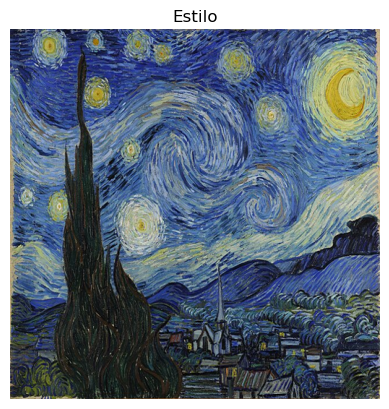

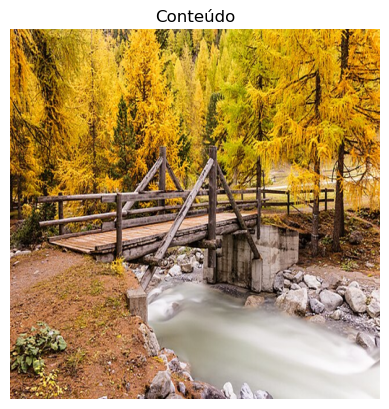

In [3]:
def load_image_from_url(url, size=(512, 512)):
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)",
        "Accept-Encoding": "identity"
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    image = image.resize(size)
    loader = transforms.ToTensor()
    return loader(image).unsqueeze(0)

style_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/640px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"
content_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/S-charl%2C_Clemgia_zijrivier_van_de_Inn._12-10-2024._%28d.j.b%29_04.jpg/640px-S-charl%2C_Clemgia_zijrivier_van_de_Inn._12-10-2024._%28d.j.b%29_04.jpg"

style_img = load_image_from_url(style_url)
content_img = load_image_from_url(content_url)

imshow(style_img, title="Estilo")
imshow(content_img, title="Conteúdo")

## 10.4. Definir funções de perda

A transferência de estilo é guiada por duas componentes de perda complementares:

- **ContentLoss** — mede o desvio entre as ativações da imagem gerada e as da imagem de conteúdo,  
  garantindo que a estrutura global e os objetos principais permanecem reconhecíveis.

- **StyleLoss** — mede a diferença entre as *Gram matrices* das ativações,  
  que capturam padrões de textura e correlações entre canais, preservando assim o estilo visual.

O cálculo da *Gram matrix* transforma as ativações em representações de correlação entre filtros,  
permitindo que o modelo aprenda a replicar padrões de cor e textura, e não a forma exata dos objetos.

In [4]:
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(b * c, h * w)
    G = torch.mm(features, features.t())
    return G.div(b * c * h * w)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

## 10.5. Criar modelo e extrair características da VGG

Aqui é criada a arquitetura usada para extrair as características de **conteúdo** e **estilo**.

- Utiliza-se a **VGG-19 pré-treinada**, uma rede convolucional profunda conhecida por representar bem texturas e estruturas visuais.  
- O modelo é percorrido camada a camada, e em determinados pontos são introduzidos módulos que calculam:
  - `ContentLoss` — mede a semelhança com a imagem de conteúdo;
  - `StyleLoss` — mede a semelhança com a imagem de estilo.

A função `get_style_model_and_losses()` constrói dinamicamente um novo modelo que intercala:
1. Normalização das entradas (compatível com o treino original da VGG);
2. Camadas convolucionais da VGG-19;
3. Camadas auxiliares de cálculo de perdas.

O resultado é um modelo que, ao ser usado na otimização, **mantém a estrutura da imagem de conteúdo** e **adota o padrão visual do estilo**.

In [5]:
cnn = models.vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()

content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.clone().view(-1, 1, 1)
        self.std = std.clone().view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

def get_style_model_and_losses(cnn, style_img, content_img):
    cnn = copy.deepcopy(cnn)
    normalization = Normalization(normalization_mean, normalization_std).to(device)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0  # contador de conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f"conv_{i}"
        elif isinstance(layer, nn.ReLU):
            name = f"relu_{i}"
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{i}"
        elif isinstance(layer, nn.BatchNorm2d):
            name = f"bn_{i}"
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    return model[:], style_losses, content_losses

## 10.6. Inicializar a imagem de entrada

Antes de iniciar o processo de *Neural Style Transfer*, é necessário definir:

- **`input_img`** — a imagem que será otimizada.  
  Pode começar como uma imagem aleatória (`torch.randn`) ou como uma cópia da imagem de conteúdo (inicialização mais estável).  
  Durante o treino, os seus valores de píxeis serão atualizados iterativamente até combinar conteúdo e estilo.

- **Modelo e perdas** — são criados pela função `get_style_model_and_losses()`, que devolve:
  - o modelo VGG modificado,
  - a lista de perdas de estilo,
  - e a lista de perdas de conteúdo.

- **Otimizador LBFGS** — é um método de otimização de segunda ordem,  
  particularmente eficaz em problemas de ajuste fino de imagens, onde o número de parâmetros é pequeno (os píxeis da imagem).  
  Ele ajusta diretamente os valores da imagem de entrada para minimizar a soma ponderada das perdas.

In [6]:
input_img = torch.randn(content_img.data.size()).to(device)

#input_img = content_img.clone()
input_img.requires_grad_(True)

model, style_losses, content_losses = get_style_model_and_losses(cnn, style_img, content_img)

optimizer = optim.LBFGS([input_img])

## 10.7. Otimizar a imagem

Nesta célula decorre o processo de **transferência de estilo neural**,  
onde a imagem gerada é ajustada iterativamente para equilibrar **conteúdo** e **estilo**.

**Parâmetros principais**

- **`style_weight`** — controla a força com que o padrão visual da imagem de estilo é imposto.  
  - Valores **mais altos** (ex: `1e7` ou `1e8`) produzem resultados com *pinceladas* e texturas mais fortes.  
  - Valores **mais baixos** (ex: `1e5` ou `1e6`) preservam melhor a estrutura e cores do conteúdo.

- **`content_weight`** — regula a fidelidade à imagem de conteúdo.  
  - Valores **altos** (ex: `1e2` ou `1e3`) mantêm a composição original quase intacta.  
  - Valores **baixos** tornam o resultado mais abstrato.

O equilíbrio entre estes dois pesos determina a aparência final.  
Explorar combinações é uma excelente forma de perceber o papel relativo das representações internas na VGG.

**Outras variáveis ajustáveis**

- **`num_steps`** — número de iterações de otimização (tipicamente 200–400).  
  - Valores maiores refinam o resultado, mas aumentam o tempo de execução.

- **`input_img` inicial** — pode ser ruído ou uma cópia da imagem de conteúdo.  
  - A inicialização com a imagem de conteúdo tende a convergir mais rapidamente e com menos artefactos.

**Nota pedagógica:**
A experimentação destes parâmetros é essencial para compreender:
- como diferentes camadas da VGG codificam informação semântica e visual;
- e como pequenas variações nos pesos alteram profundamente o equilíbrio entre forma (*conteúdo*) e textura (*estilo*).

Trata-se de um excelente exemplo de **interpretação qualitativa** de redes neuronais convolucionais.

Otimizando estilo: 320it [04:54,  1.09it/s, style_loss=82.45, content_loss=534.55]


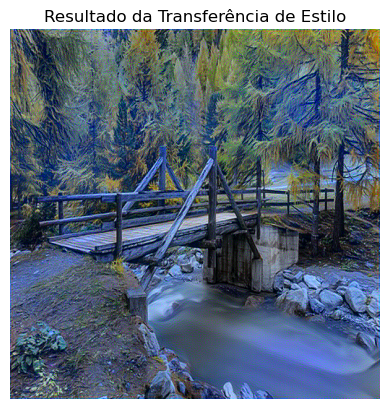

In [7]:
style_weight = 1e6 # 1e7 ou 1e8 para efeito mais dramático
content_weight = 1e2 # 1e0 ou 1e2 para preservar mais estrutura

num_steps = 300
run = [0]

pbar = tqdm(total=num_steps, desc="Otimizando estilo")

while run[0] <= num_steps:

    def closure():
        input_img.data.clamp_(0, 1)
        optimizer.zero_grad()
        model(input_img)
        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        # 💡 Aplica os pesos aqui
        style_score *= style_weight
        content_score *= content_weight

        loss = style_score + content_score
        loss.backward()

        run[0] += 1
        pbar.update(1)
        if run[0] % 50 == 0:
            pbar.set_postfix({
                "style_loss": f"{style_score.item():.2f}",
                "content_loss": f"{content_score.item():.2f}"
            })

        return loss

    optimizer.step(closure)

pbar.close()
input_img.data.clamp_(0, 1)
imshow(input_img.detach(), title='Resultado da Transferência de Estilo')

## 10.8. Face-swapping: verificação prévia de deteção facial

Uma variação conceptual do style transfer é o face-swap, hoje em dia já bastante robusto, e que ensaiaremos numa versão simples e estática de seguida.
No entanto, antes de proceder ao *face-swap*, é essencial confirmar se o modelo consegue detetar os rostos nas imagens de origem e de destino.  
Esta célula utiliza o **InsightFace** com o modelo `antelopev2`, mais robusto a inclinações e variações de iluminação.

O procedimento é o seguinte:
1. Carrega ambas as imagens locais (`face_src.jpg`, `face_tgt.jpg`);
2. Executa a deteção facial;
3. Mostra as *bounding boxes* e pontos de referência principais (landmarks);
4. Informa o número de rostos detetados em cada imagem.

Caso algum rosto não seja detetado, recomenda-se:
- Utilizar imagens mais centradas e com a face em posição frontal;
- Ajustar `det_size` ou trocar o modelo (`buffalo_l` ou `antelopev2`);
- Confirmar que as imagens estão em formato RGB e com resolução adequada.

Se ambas as faces forem detetadas corretamente, pode-se prosseguir com a substituição facial.

/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/w600k_r50.onnx recognition [

/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


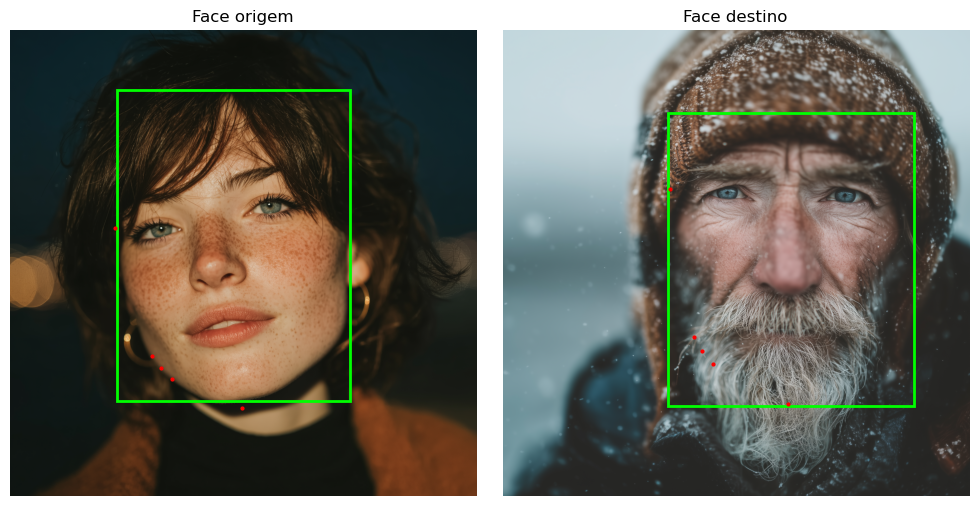

Rostos detetados — origem: 1, destino: 1
Ambas as faces foram detetadas corretamente.


In [8]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))
print("Modelo carregado com sucesso.")

src_path = "face_src.png"   # substitui pelo nome real
tgt_path = "face_tgt.png"   # substitui pelo nome real
src_img = Image.open(src_path).convert("RGB")
tgt_img = Image.open(tgt_path).convert("RGB")

src_np = np.array(src_img)
tgt_np = np.array(tgt_img)

faces_src = app.get(src_np)
faces_tgt = app.get(tgt_np)

def show_face_detections(image, faces, title):
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    for f in faces:
        x1, y1, x2, y2 = [int(v) for v in f.bbox]
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                          fill=False, color='lime', linewidth=2))
        for (x, y) in f.landmark_2d_106[:5]: 
            plt.plot(x, y, 'ro', markersize=2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
show_face_detections(src_np, faces_src, "Face origem")
plt.subplot(1, 2, 2)
show_face_detections(tgt_np, faces_tgt, "Face destino")
plt.tight_layout()
plt.show()


print(f"Rostos detetados — origem: {len(faces_src)}, destino: {len(faces_tgt)}")

if not faces_src or not faces_tgt:
    print("Pelo menos uma das imagens não contém um rosto detetável.")
else:
    print("Ambas as faces foram detetadas corretamente.")

## 10.9. Face-swap conceptual com embeddings faciais e difusão estável

Atenção: horrivelmente lento no CPU, testar em GPU.

Esta célula demonstra uma **abordagem conceptual de substituição facial** (*face-swap*) entre duas imagens estáticas,  
sem recorrer a modelos especializados de reconstrução facial ou *morphing* explícito.  
A ideia é combinar **descrições latentes de identidade** (geradas com *InsightFace*) com **síntese de imagem** via *Stable Diffusion*.

**Etapas do processo**

1. **Carregamento e preparação dos modelos**
   - O *Stable Diffusion v1-5* é carregado para gerar imagens realistas a partir de *prompts* textuais.  
   - O *InsightFace* é utilizado apenas para extrair *embeddings* faciais — vetores de identidade de alta dimensão.

2. **Leitura das imagens de origem e destino**
   - Ambas são redimensionadas para 512×512 px e convertidas para RGB.  
   - São mostradas lado a lado para referência visual.

3. **Extração e mistura de embeddings**
   - O modelo `buffalo_l` do InsightFace deteta e codifica os rostos.  
   - Os *embeddings* de origem e destino são combinados linearmente (exemplo: 70 % destino + 30 % origem).  
   - O vetor resultante representa uma identidade híbrida — um rosto sintético situado entre ambos.

4. **Geração com *Stable Diffusion***
   - O *prompt* textual define o contexto visual (ex.: *portrait photograph, realistic lighting*).  
   - O gerador de difusão cria uma nova imagem coerente com o texto e o vetor latente resultante.  
   - O parâmetro `guidance_scale` controla a força da aderência ao *prompt* (maior → mais literal).

5. **Visualização do resultado**
   - A imagem final ilustra o conceito de **transferência parcial de identidade** em ambiente de difusão,  
     isto é, uma *simulação de face-swap neural* obtida por fusão latente.

**Notas pedagógicas**

- Esta abordagem **não é um face-swap realista**, pois não realiza substituição geométrica,  
  preservação de iluminação ou alinhamento pixel-a-pixel.  
  O objetivo é ilustrar o princípio de mistura de representações latentes entre duas identidades faciais.

- Pequenas alterações em:
  - `alpha` → controlam a proporção de traços herdados do rosto original;
  - `guidance_scale` e `num_inference_steps` → ajustam o equilíbrio entre fidelidade e criatividade.

- O mesmo conceito pode ser explorado para:
  - *Morphing* de identidades (trajetórias no espaço latente);
  - Análise de invariância semântica em embeddings faciais;
  - Experiências sobre controle simbólico da geração visual.

> **Aviso ético:** este código destina-se exclusivamente a fins de investigação e ensino.  
> Não deve ser utilizado para criar, publicar ou difundir representações falsas de pessoas reais sem consentimento.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


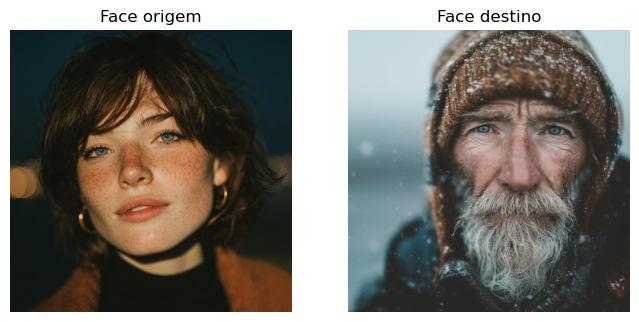

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/pedropestana/.insightface/models/buffalo_l/w600k_r50.onnx recognition [

  0%|          | 0/30 [00:00<?, ?it/s]

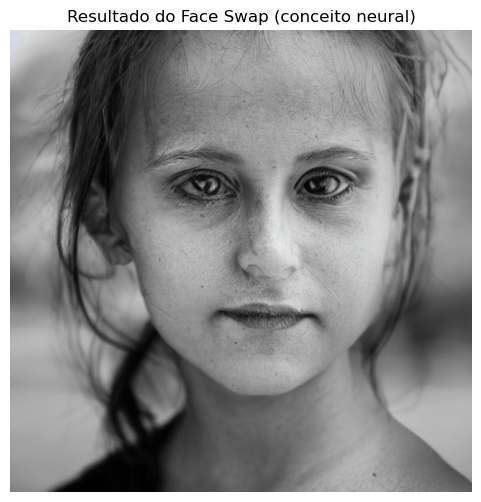

In [9]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
).to(device)

src_img = Image.open("face_src.png").convert("RGB").resize((512, 512))
tgt_img = Image.open("face_tgt.png").convert("RGB").resize((512, 512))

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(src_img); ax[0].set_title("Face origem")
ax[1].imshow(tgt_img); ax[1].set_title("Face destino")
for a in ax: a.axis("off")
plt.show()

app = FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640,640))

faces_src = app.get(np.array(src_img))
faces_tgt = app.get(np.array(tgt_img))

if not faces_src or not faces_tgt:
    raise RuntimeError("Não foi possível detetar ambos os rostos.")

embedding_src = torch.tensor(faces_src[0].embedding).unsqueeze(0)
embedding_tgt = torch.tensor(faces_tgt[0].embedding).unsqueeze(0)

alpha = 0.3
mixed_embedding = (1 - alpha) * embedding_tgt + alpha * embedding_src
mixed_embedding = mixed_embedding / mixed_embedding.norm(dim=-1, keepdim=True)

prompt = "portrait photograph, realistic lighting, shallow depth of field"
generator = torch.Generator(device=device).manual_seed(42)

with torch.autocast(device):
    image = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Resultado do Face Swap (conceito neural)")
plt.show()

## 10.10. [Future Work] — Avaliação Perceptual dos Pesos de Estilo e Conteúdo
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

O objetivo é estudar quantitativamente o impacto dos parâmetros `style_weight` e `content_weight`  
na qualidade perceptual das imagens geradas por *Neural Style Transfer*.

**Hipótese:** existe uma combinação ótima de pesos que equilibra a preservação estrutural (conteúdo)  
e a fidelidade estética (estilo), mensurável através de métricas perceptuais.

**Pipeline sugerido:**
1. Gerar um conjunto de imagens variando sistematicamente `style_weight` e `content_weight` (ex: grelha 5×5).  
2. Calcular métricas objetivas:
   - *SSIM* → preservação estrutural (comparar com a imagem de conteúdo);  
   - *LPIPS* ou *CLIPScore* → semelhança perceptual com a imagem de estilo.  
3. Visualizar os resultados num *heatmap* 2D (content vs style weights).  
4. Identificar regiões de equilíbrio perceptual e discutir a sua coerência visual.  

**Extensões possíveis:**
- Avaliar a estabilidade entre diferentes estilos (pintura, fotografia, arte digital);
- Correlacionar as métricas objetivas com avaliações humanas simples (ver Ideia 5).

Este estudo combina **interpretação quantitativa e estética**, sendo adequado para relatórios técnicos, dissertações curtas ou artigos aplicados.

## 10.11. [Future Work] — Contributo das Camadas da VGG na Transferência de Estilo
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Nesta variante, o foco é compreender **como diferentes camadas da rede VGG-19 contribuem para a transferência de estilo**.

**Hipótese:** camadas mais superficiais capturam padrões de textura e cor locais,  
enquanto camadas mais profundas capturam estrutura global e composição visual.

**Pipeline sugerido:**
1. Modificar a lista `style_layers` (ex: testar apenas `conv_1–3`, depois `conv_4–5`, etc.);  
2. Gerar transferências correspondentes e comparar visualmente os resultados;  
3. Calcular métricas de textura (ex: contraste, entropia, *power spectrum*) para cada versão;  
4. Analisar diferenças em termos de granularidade e coerência estrutural.

**Possíveis extensões:**
- Combinar camadas de diferentes profundidades com pesos diferenciados;
- Avaliar a interpretabilidade visual das ativações (*feature visualization*).

Este tipo de estudo contribui para uma compreensão mais fina de **como a hierarquia convolucional codifica o estilo**,  
e pode ser um excelente exercício de *explainable deep vision*.

## 10.12. [Future Work]— Avaliação Humana e Categorização Estética
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Esta proposta introduz uma componente empírica, combinando geração visual e análise de perceção humana.  
O objetivo é avaliar **como diferentes configurações de transferência de estilo são percebidas por observadores humanos**  
e se as métricas automáticas refletem essas preferências.

**Hipóteses:**
- Certas combinações de `style_weight` e `content_weight` são consistentemente preferidas pelos observadores.  
- Métricas como *CLIPScore* ou *LPIPS* correlacionam-se com o julgamento humano de qualidade estética.

**Pipeline sugerido:**
1. Gerar um conjunto de 20–30 imagens com diferentes intensidades de estilo.  
2. Criar um pequeno inquérito online (e.g., Google Forms, Qualtrics) onde os participantes avaliam:  
   - equilíbrio entre conteúdo e estilo;  
   - qualidade estética global;  
   - preferência geral.  
3. Recolher respostas de pelo menos 20 participantes (estudantes ou público geral).  
4. Calcular correlações (ex: *Spearman* ou *Pearson*) entre as avaliações humanas e as métricas objetivas.  
5. Discutir discrepâncias e implicações para modelos perceptuais automáticos.

**Extensões possíveis:**
- Avaliar diferenças culturais ou de formação artística na perceção;  
- Usar pares forçados (“qual imagem prefere?”) para simplificar o questionário.

Este tipo de investigação articula **ciência de dados, estética computacional e cognição visual**,  
sendo especialmente relevante para dissertações que cruzam IA e estudos da perceção.

## 10.13. [Future Work] — Transferência de Estilo Facial e Preservação de Identidade
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Explorar se é possível aplicar transferência de estilo **restrita à textura facial** sem alterar a identidade subjacente.  
Este estudo faz a ponte entre *Neural Style Transfer* e *Face Swapping*, explorando a fronteira entre transformação estética e preservação pessoal.

**Hipótese:** é possível estilizar um rosto (ex: emulando Van Gogh, Monet, ou arte digital)  
sem comprometer significativamente as feições que permitem reconhecer a pessoa.

**Pipeline sugerido:**
1. Criar um pequeno conjunto de retratos (3–5 pessoas).  
2. Aplicar *style transfer* com estilos pictóricos distintos (pintura, cartoon, arte digital).  
3. Usar um modelo de reconhecimento facial (ex: `face_recognition` ou `DeepFace`) para medir a semelhança embeddada antes/depois.  
4. Calcular a variação média de identidade (distância coseno entre embeddings).  
5. Relacionar a perda de identidade com o nível de distorção estética percebido.

**Extensões possíveis:**
- Avaliar que estilos “preservam” mais a identidade facial (pintura realista vs. abstração);
- Estender a análise para dados não-faciais (por exemplo, *style transfer* em imagens de paisagem urbana).

Este estudo investiga a **zona cinzenta entre criatividade e identidade**,  
relevante tanto para aplicações artísticas como para considerações éticas sobre manipulação facial.

## 10.14. Conclusão

Neste notebook vimos como uma rede convolucional pode ser usada para combinar conteúdo e estilo de imagens diferentes. Esta técnica, embora computacionalmente exigente, tem aplicações tanto artísticas como técnicas, e é uma porta de entrada para redes generativas mais complexas.